In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/train.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.shape

(614, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df.describe(include="object")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [7]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

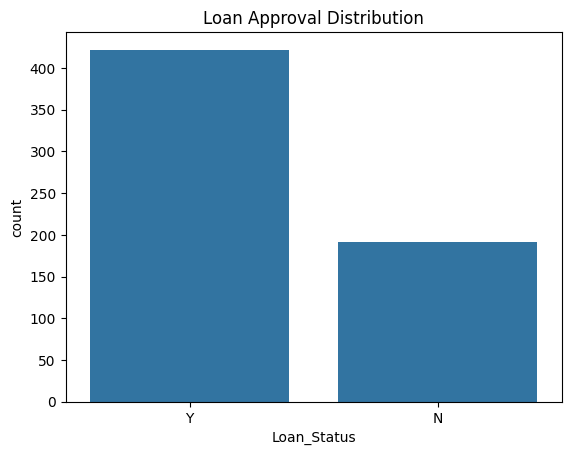

In [9]:
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Approval Distribution")
plt.show()

In [10]:
missing = (
    df.isnull().sum() / len(df)
) * 100

missing = missing.sort_values(ascending=False)

missing

Credit_History       8.143322
Self_Employed        5.211726
LoanAmount           3.583062
Dependents           2.442997
Loan_Amount_Term     2.280130
Gender               2.117264
Married              0.488599
Education            0.000000
Loan_ID              0.000000
CoapplicantIncome    0.000000
ApplicantIncome      0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

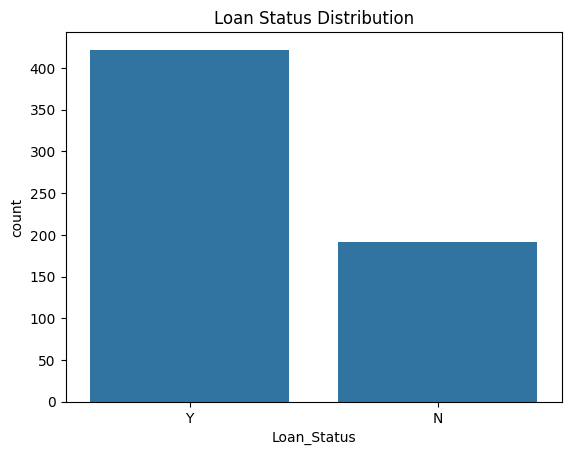

In [11]:
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Status Distribution")
plt.show()

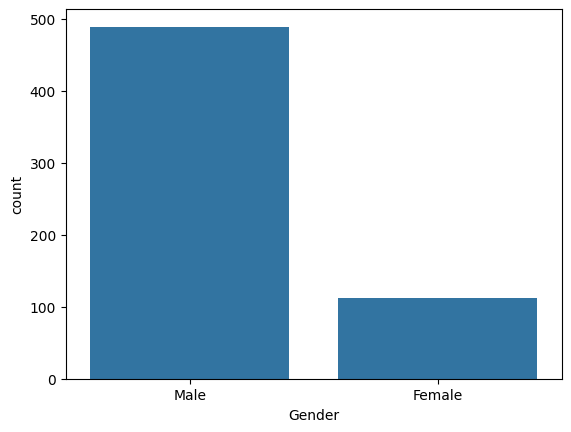

In [12]:
sns.countplot(x="Gender", data=df)
plt.show()

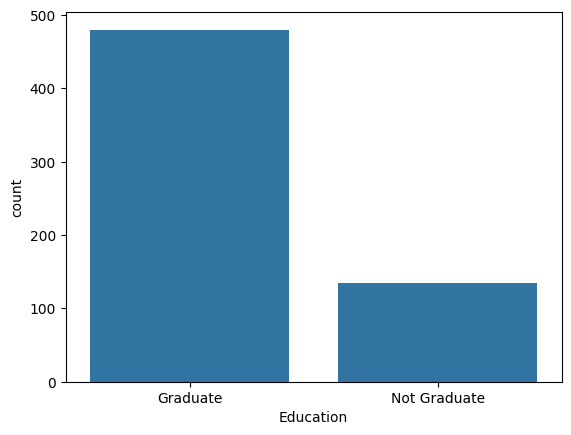

In [13]:
sns.countplot(x="Education", data=df)
plt.show()

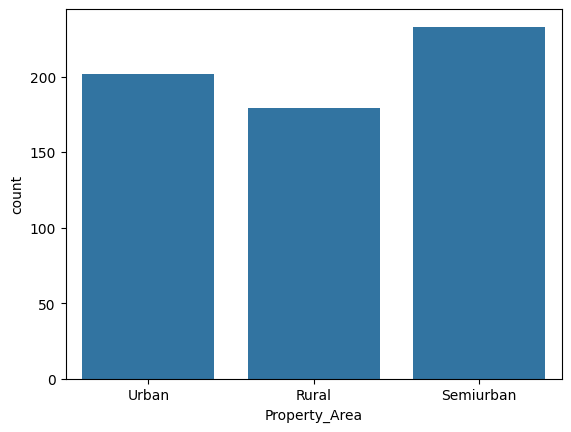

In [14]:
sns.countplot(x="Property_Area", data=df)
plt.show()

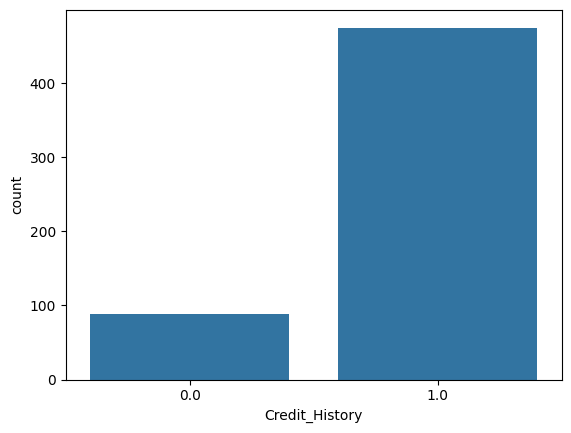

In [15]:
sns.countplot(x="Credit_History", data=df)
plt.show()

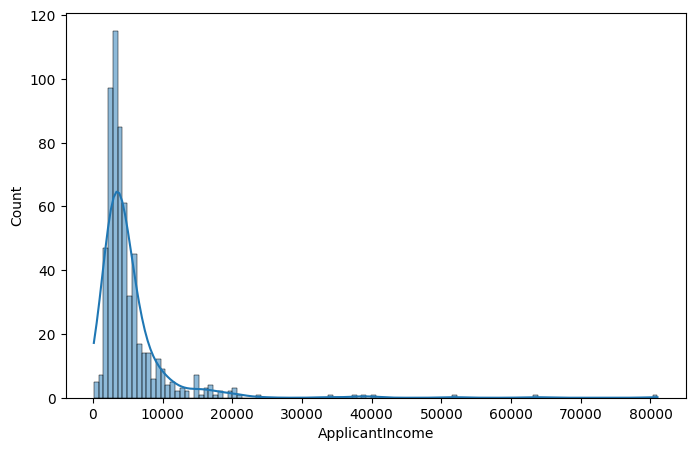

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["ApplicantIncome"], kde=True)

plt.show()

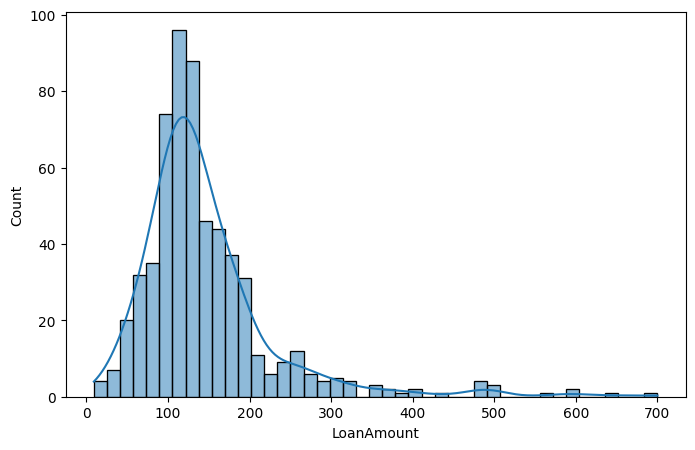

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["LoanAmount"], kde=True)

plt.show()

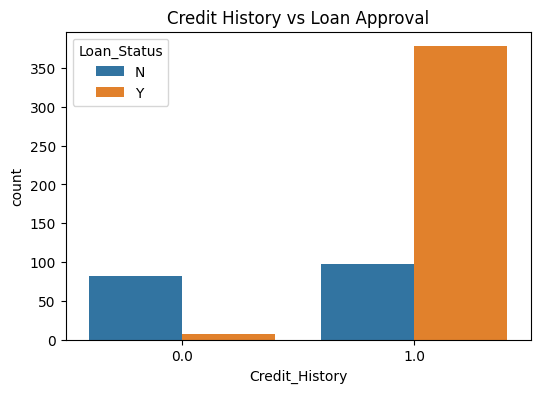

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Credit_History",
    hue="Loan_Status",
    data=df
)

plt.title("Credit History vs Loan Approval")

plt.show()

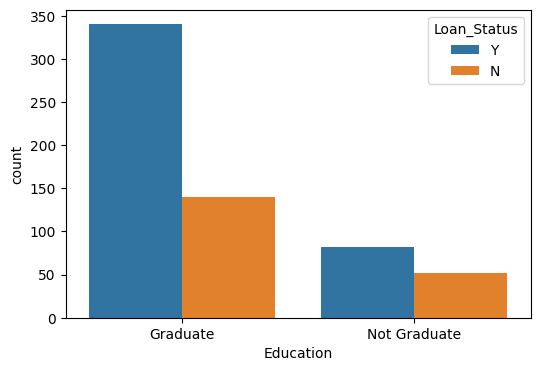

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Education",
    hue="Loan_Status",
    data=df
)

plt.show()

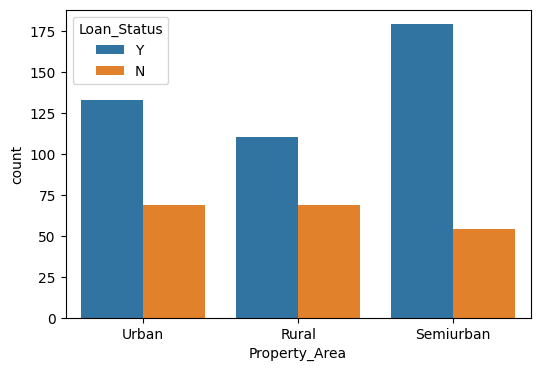

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Property_Area",
    hue="Loan_Status",
    data=df
)

plt.show()

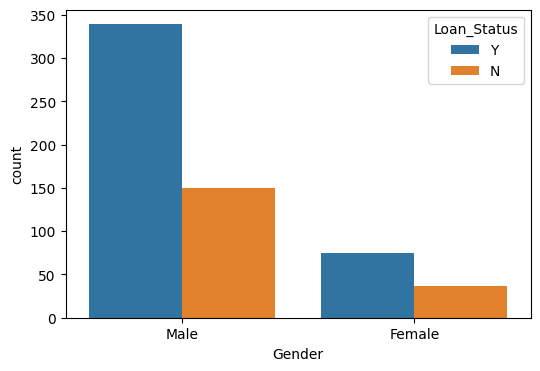

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Gender",
    hue="Loan_Status",
    data=df
)

plt.show()

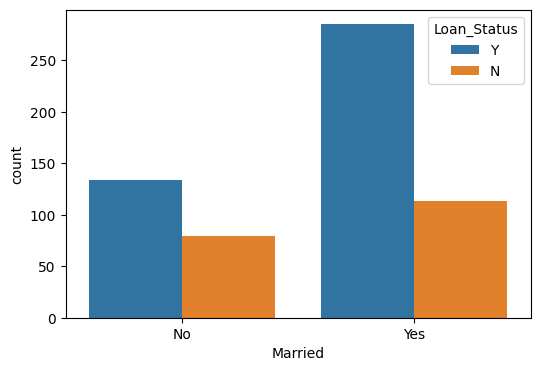

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Married",
    hue="Loan_Status",
    data=df
)

plt.show()

In [23]:
df["TotalIncome"] = (
    df["ApplicantIncome"] +
    df["CoapplicantIncome"]
)

In [24]:
df["TotalIncome"].describe()

count      614.000000
mean      7024.705081
std       6458.663872
min       1442.000000
25%       4166.000000
50%       5416.500000
75%       7521.750000
max      81000.000000
Name: TotalIncome, dtype: float64

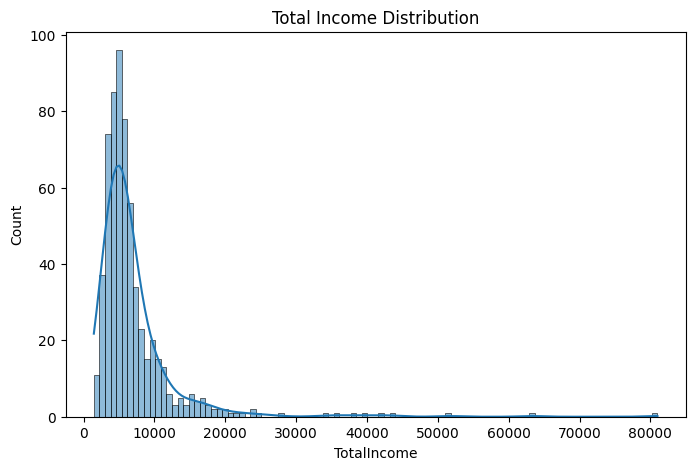

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["TotalIncome"],
    kde=True
)

plt.title("Total Income Distribution")

plt.show()

In [27]:
df[["TotalIncome","Income_Loan_Ratio"]].head()

,TotalIncome,Income_Loan_Ratio
0,5849.0,NaN
1,6091.0,47.585938
2,3000.0,45.454545
3,4941.0,41.175000
4,6000.0,42.553191


In [28]:
df.drop("Loan_ID", axis=1, inplace=True)

In [29]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)

df["Married"].fillna(df["Married"].mode()[0], inplace=True)

df["Dependents"].fillna(df["Dependents"].mode()[0], inplace=True)

df["Self_Employed"].fillna(df["Self_Employed"].mode()[0], inplace=True)

df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)

df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0], inplace=True)

df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)

C:\Users\sasmi\AppData\Local\Temp\ipykernel_98612\4286976478.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
C:\Users\sasmi\AppData\Local\Temp\ipykernel_98612\4286976478.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [30]:
df.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
TotalIncome           0
Income_Loan_Ratio    22
dtype: int64

In [34]:
df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)

C:\Users\sasmi\AppData\Local\Temp\ipykernel_98612\471380255.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)


In [35]:
df["Income_Loan_Ratio"] = (
    df["TotalIncome"] /
    df["LoanAmount"]
)

In [36]:
df["Income_Loan_Ratio"].isnull().sum()

np.int64(0)

In [37]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [38]:
df["Loan_Status"] = df["Loan_Status"].map({
    "Y":1,
    "N":0
})

In [39]:
df = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Self_Employed",
        "Property_Area"
    ],
    drop_first=True
)

In [40]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
model = LogisticRegression(max_iter=1000)

In [45]:
model.fit(X_train, y_train)

c:\Users\sasmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [48]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.7886178861788617
[[18 25]
 [ 1 79]]
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [49]:
from sklearn.tree import DecisionTreeClassifier

In [50]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [51]:
dt_pred = dt.predict(X_test)

In [52]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Decision Tree Accuracy")

print(
    accuracy_score(
        y_test,
        dt_pred
    )
)

print(
    confusion_matrix(
        y_test,
        dt_pred
    )
)

print(
    classification_report(
        y_test,
        dt_pred
    )
)

Decision Tree Accuracy
0.6666666666666666
[[21 22]
 [19 61]]
              precision    recall  f1-score   support

           0       0.53      0.49      0.51        43
           1       0.73      0.76      0.75        80

    accuracy                           0.67       123
   macro avg       0.63      0.63      0.63       123
weighted avg       0.66      0.67      0.66       123



In [53]:
from sklearn.ensemble import RandomForestClassifier


In [54]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
rf_pred = rf.predict(X_test)

In [56]:
print("Random Forest Accuracy")
print(accuracy_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy
0.8048780487804879
[[23 20]
 [ 4 76]]
              precision    recall  f1-score   support

           0       0.85      0.53      0.66        43
           1       0.79      0.95      0.86        80

    accuracy                           0.80       123
   macro avg       0.82      0.74      0.76       123
weighted avg       0.81      0.80      0.79       123



In [57]:
from sklearn.neighbors import KNeighborsClassifier

In [58]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [59]:
knn_pred = knn.predict(X_test)

In [60]:
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.5691056910569106
[[ 5 38]
 [15 65]]
              precision    recall  f1-score   support

           0       0.25      0.12      0.16        43
           1       0.63      0.81      0.71        80

    accuracy                           0.57       123
   macro avg       0.44      0.46      0.43       123
weighted avg       0.50      0.57      0.52       123



In [61]:
from sklearn.preprocessing import StandardScaler

In [62]:
scaler = StandardScaler()

In [63]:
X_train_scaled = scaler.fit_transform(X_train)

In [64]:
X_test_scaled = scaler.transform(X_test)

In [65]:
from sklearn.neighbors import KNeighborsClassifier

In [66]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

In [67]:
knn.fit(
    X_train_scaled,
    y_train
)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [68]:
knn_pred = knn.predict(
    X_test_scaled
)

In [69]:
print("KNN Accuracy")

print(
    accuracy_score(
        y_test,
        knn_pred
    )
)

print(
    confusion_matrix(
        y_test,
        knn_pred
    )
)

print(
    classification_report(
        y_test,
        knn_pred
    )
)

KNN Accuracy
0.7560975609756098
[[17 26]
 [ 4 76]]
              precision    recall  f1-score   support

           0       0.81      0.40      0.53        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.78      0.67      0.68       123
weighted avg       0.77      0.76      0.73       123



In [70]:
from sklearn.model_selection import RandomizedSearchCV

In [71]:
params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [72]:
rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

In [73]:
random_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [74]:
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}
0.8206761492475778


In [75]:
best_rf = random_search.best_estimator_

best_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, best_pred))
print(confusion_matrix(y_test, best_pred))
print(classification_report(y_test, best_pred))

Accuracy: 0.7886178861788617
[[21 22]
 [ 4 76]]
              precision    recall  f1-score   support

           0       0.84      0.49      0.62        43
           1       0.78      0.95      0.85        80

    accuracy                           0.79       123
   macro avg       0.81      0.72      0.74       123
weighted avg       0.80      0.79      0.77       123



In [76]:
print(random_search.best_params_)

{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}


In [77]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [78]:
rf


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
rf.feature_importances_

array([0.11047156, 0.07137887, 0.11666586, 0.03935275, 0.25385193,
       0.13492145, 0.13287852, 0.01423434, 0.0196134 , 0.01673975,
       0.00918142, 0.00929219, 0.0183425 , 0.01295422, 0.02455712,
       0.01556413])

In [81]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,Credit_History,0.253852
5,TotalIncome,0.134921
6,Income_Loan_Ratio,0.132879
2,LoanAmount,0.116666
0,ApplicantIncome,0.110472
1,CoapplicantIncome,0.071379
3,Loan_Amount_Term,0.039353
14,Property_Area_Semiurban,0.024557
8,Married_Yes,0.019613
12,Education_Not Graduate,0.018342


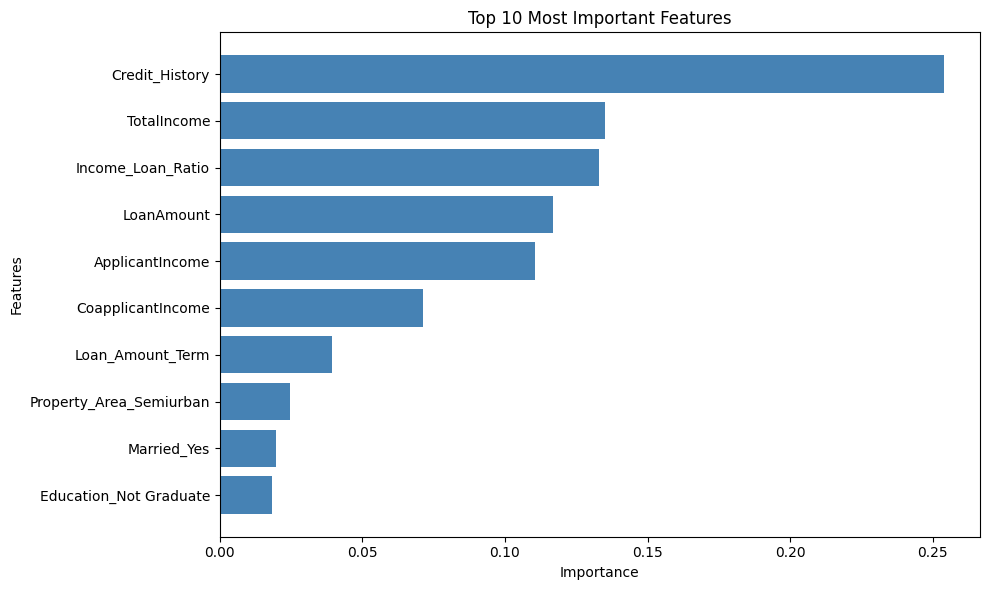

In [82]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10],
    color="steelblue"
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features")

plt.tight_layout()

plt.show()